# 🚧 Pothole Detection & Road Damage Analysis
### YOLOv8 + Flask Web Application

**Abstract:** This notebook trains a YOLOv8 model on a Roboflow pothole dataset and exports it for use in a Flask web application for real-time road damage analysis.

---
**Pipeline:**
1. Install dependencies
2. Download dataset from Roboflow
3. Train YOLOv8 model
4. Evaluate & visualize results
5. Run inference on sample images/videos
6. Export model for Flask deployment

## Step 1: Install Dependencies

In [1]:
# Check GPU availability
!nvidia-smi

# Install required packages
!pip install ultralytics roboflow supervision opencv-python-headless matplotlib seaborn pandas -q

print("✅ Dependencies installed successfully!")

Fri Apr 10 10:12:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from ultralytics import YOLO
from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore')

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Using device: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🖥️  Using device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## Step 2: Download Dataset from Roboflow

> **Note:** Replace the API key and project details with your own Roboflow credentials.
>
> Recommended public datasets:
> - `"pothole-detection-system"` by roboflow-100
> - `"road-damage-detection"` by various contributors

In [4]:
from roboflow import Roboflow

# ============================================================
# CONFIGURE YOUR ROBOFLOW CREDENTIALS HERE
# ============================================================
# ROBOFLOW_API_KEY = "LDsRnSKXjdefmWcaLGcs"   # <-- Replace with your key
# WORKSPACE = "roboflow-100"               # <-- Your workspace name
# PROJECT   = "pothole-detection-system"   # <-- Your project name
# VERSION   = 1                            # <-- Dataset version

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="LDsRnSKXjdefmWcaLGcs")
project = rf.workspace("aegis").project("pothole-detection-i00zy")
version = project.version(10)
dataset = version.download("yolov8")

# ============================================================

# rf = Roboflow(api_key=ROBOFLOW_API_KEY)
# project = rf.workspace(WORKSPACE).project(PROJECT)
# dataset = project.version(VERSION).download("yolov8")

# DATASET_PATH = dataset.location
# print(f"\n✅ Dataset downloaded to: {DATASET_PATH}")

loading Roboflow workspace...
loading Roboflow project...


In [5]:
DATASET_PATH = "/content/Pothole-Detection--10"

In [8]:
# Explore dataset structure
import yaml

data_yaml = f"{DATASET_PATH}/data.yaml"
with open(data_yaml, 'r') as f:
    data_config = yaml.safe_load(f)

print("📊 Dataset Configuration:")
print(f"   Classes : {data_config.get('names', [])}")
print(f"   Num Classes: {data_config.get('nc', 'N/A')}")

# Count images per split
for split in ['train', 'valid', 'test']:
    split_img_path = os.path.join(DATASET_PATH, split, 'images')
    if os.path.exists(split_img_path):
        count = len(os.listdir(split_img_path))
        print(f"   {split.capitalize():8s}: {count} images")

📊 Dataset Configuration:
   Classes : ['pothole']
   Num Classes: 1
   Train   : 3043 images
   Valid   : 273 images
   Test    : 174 images


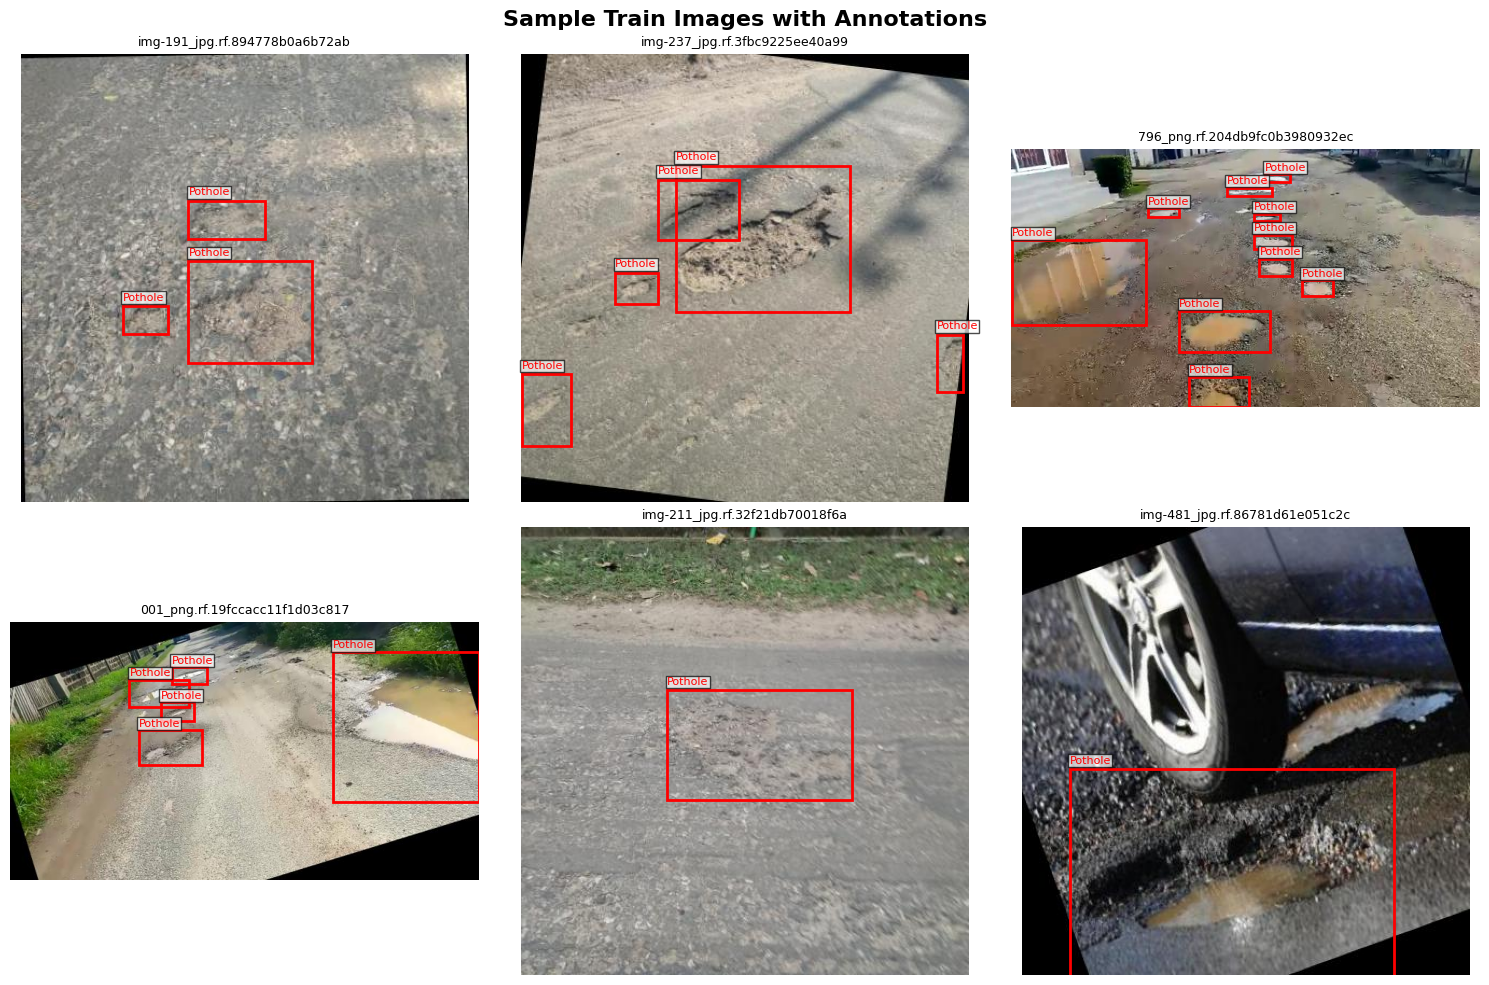

✅ Sample visualization saved to /content/sample_images.png


In [9]:
# Visualize sample training images with labels
def visualize_samples(dataset_path, split='train', num_samples=6):
    img_dir = os.path.join(dataset_path, split, 'images')
    lbl_dir = os.path.join(dataset_path, split, 'labels')

    images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:num_samples]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Sample {split.capitalize()} Images with Annotations', fontsize=16, fontweight='bold')

    for idx, (ax, img_file) in enumerate(zip(axes.flat, images)):
        img_path = os.path.join(img_dir, img_file)
        lbl_path = os.path.join(lbl_dir, img_file.rsplit('.', 1)[0] + '.txt')

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        ax.imshow(img)
        ax.set_title(img_file[:30], fontsize=9)
        ax.axis('off')

        # Draw bounding boxes from YOLO labels
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls, cx, cy, bw, bh = int(parts[0]), *map(float, parts[1:5])
                        x1 = (cx - bw/2) * w
                        y1 = (cy - bh/2) * h
                        rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                                 linewidth=2, edgecolor='red', facecolor='none')
                        ax.add_patch(rect)
                        ax.text(x1, y1-5, f'Pothole', color='red', fontsize=8,
                                bbox=dict(facecolor='white', alpha=0.7, pad=1))

    plt.tight_layout()
    plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Sample visualization saved to /content/sample_images.png")

visualize_samples(DATASET_PATH)

## Step 3: Train YOLOv8 Model

In [10]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================
MODEL_SIZE  = 'yolov8s'   # Options: n (nano), s (small), m (medium), l (large), x (xlarge)
EPOCHS      = 50          # Increase to 100-200 for better accuracy
IMG_SIZE    = 640         # Standard YOLOv8 input size
BATCH_SIZE  = 16          # Reduce to 8 if CUDA OOM
PROJECT_DIR = '/pothole_detection'
RUN_NAME    = 'yolov8_pothole_v1'
# ============================================================

print(f"Training Configuration:")
print(f"  Model     : {MODEL_SIZE}.pt")
print(f"  Epochs    : {EPOCHS}")
print(f"  Image Size: {IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Device    : {device}")

Training Configuration:
  Model     : yolov8s.pt
  Epochs    : 50
  Image Size: 640
  Batch Size: 16
  Device    : cuda


In [11]:
# Initialize and train the model
model = YOLO(f'{MODEL_SIZE}.pt')  # Downloads pretrained COCO weights

results = model.train(
    data=data_yaml,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    project=PROJECT_DIR,
    name=RUN_NAME,
    device=0 if device == 'cuda' else 'cpu',
    # Augmentation settings
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    # Training settings
    patience=20,
    save=True,
    plots=True,
    verbose=True
)

BEST_MODEL_PATH = f'{PROJECT_DIR}/{RUN_NAME}/weights/best.pt'
print(f"\n✅ Training complete!")
print(f"   Best model saved to: {BEST_MODEL_PATH}")

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pothole-Detection--10/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_pothole_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [ ]:
BEST_MODEL_PATH

## Step 4: Evaluate Model Performance

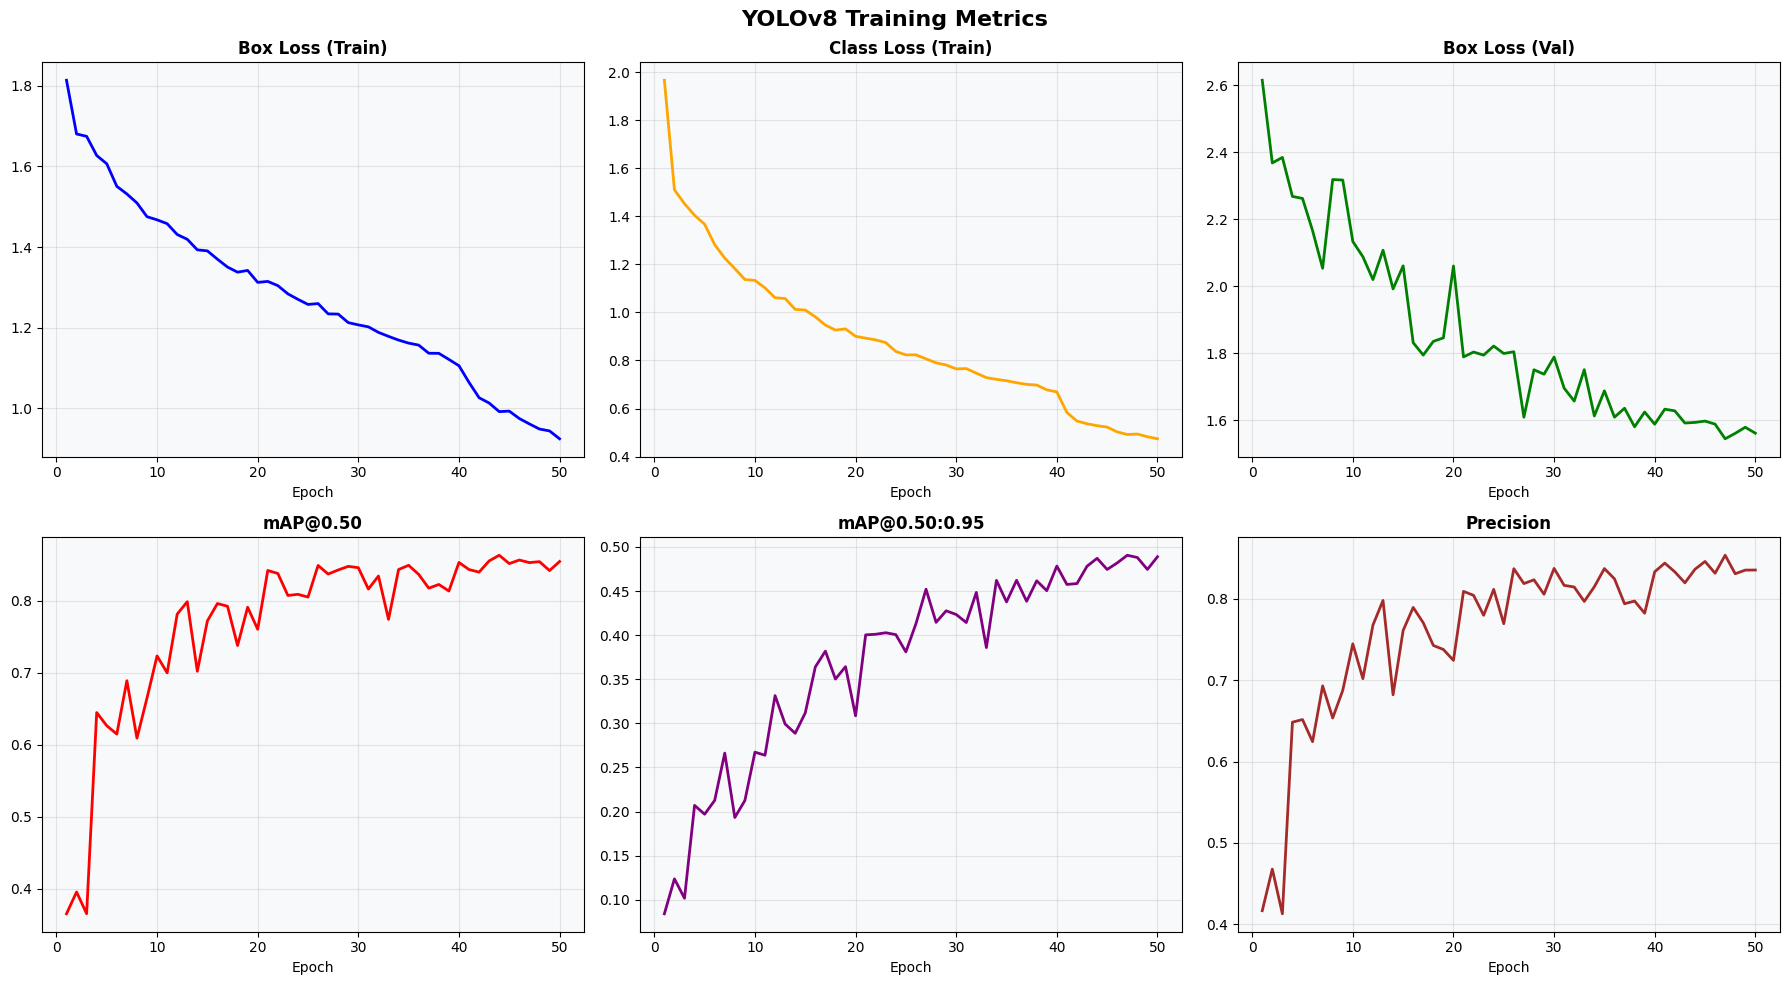

✅ Training curves saved!


In [12]:
# Plot training curves
run_dir = f'{PROJECT_DIR}/{RUN_NAME}'
results_csv = os.path.join(run_dir, 'results.csv')

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('YOLOv8 Training Metrics', fontsize=16, fontweight='bold')

    metrics = [
        ('train/box_loss',   'Box Loss (Train)',       'blue'),
        ('train/cls_loss',   'Class Loss (Train)',     'orange'),
        ('val/box_loss',     'Box Loss (Val)',          'green'),
        ('metrics/mAP50(B)', 'mAP@0.50',               'red'),
        ('metrics/mAP50-95(B)', 'mAP@0.50:0.95',      'purple'),
        ('metrics/precision(B)', 'Precision',          'brown'),
    ]

    for ax, (col, title, color) in zip(axes.flat, metrics):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], color=color, linewidth=2)
            ax.set_title(title, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.grid(True, alpha=0.3)
            ax.set_facecolor('#f8f9fa')

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Training curves saved!")
else:
    print("⚠️ results.csv not found. Run training first.")

In [13]:
# Validate on test set
best_model = YOLO(BEST_MODEL_PATH)

val_results = best_model.val(
    data=data_yaml,
    split='test',
    imgsz=IMG_SIZE,
    device=0 if device == 'cuda' else 'cpu'
)

print("\n📊 Test Set Evaluation Results:")
print(f"   mAP@0.50     : {val_results.box.map50:.4f}")
print(f"   mAP@0.50:0.95: {val_results.box.map:.4f}")
print(f"   Precision    : {val_results.box.mp:.4f}")
print(f"   Recall       : {val_results.box.mr:.4f}")

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 12.3±11.0 MB/s, size: 43.4 KB)
val: Scanning /content/Pothole-Detection--10/test/labels... 174 images, 23 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 646.0it/s 0.3s
val: New cache created: /content/Pothole-Detection--10/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.4it/s 4.6s
                   all        174        605      0.859      0.756      0.846      0.477
Speed: 4.2ms preprocess, 7.9ms inference, 0.0ms loss, 2.7ms postprocess per image
Results saved to /content/runs/detect/val

📊 Test Set Evaluation Results:
   mAP@0.50     : 0.8459
   mAP@0.50:0.95: 0.4773
   Precision    : 0.8591
   Recall       : 0.7558


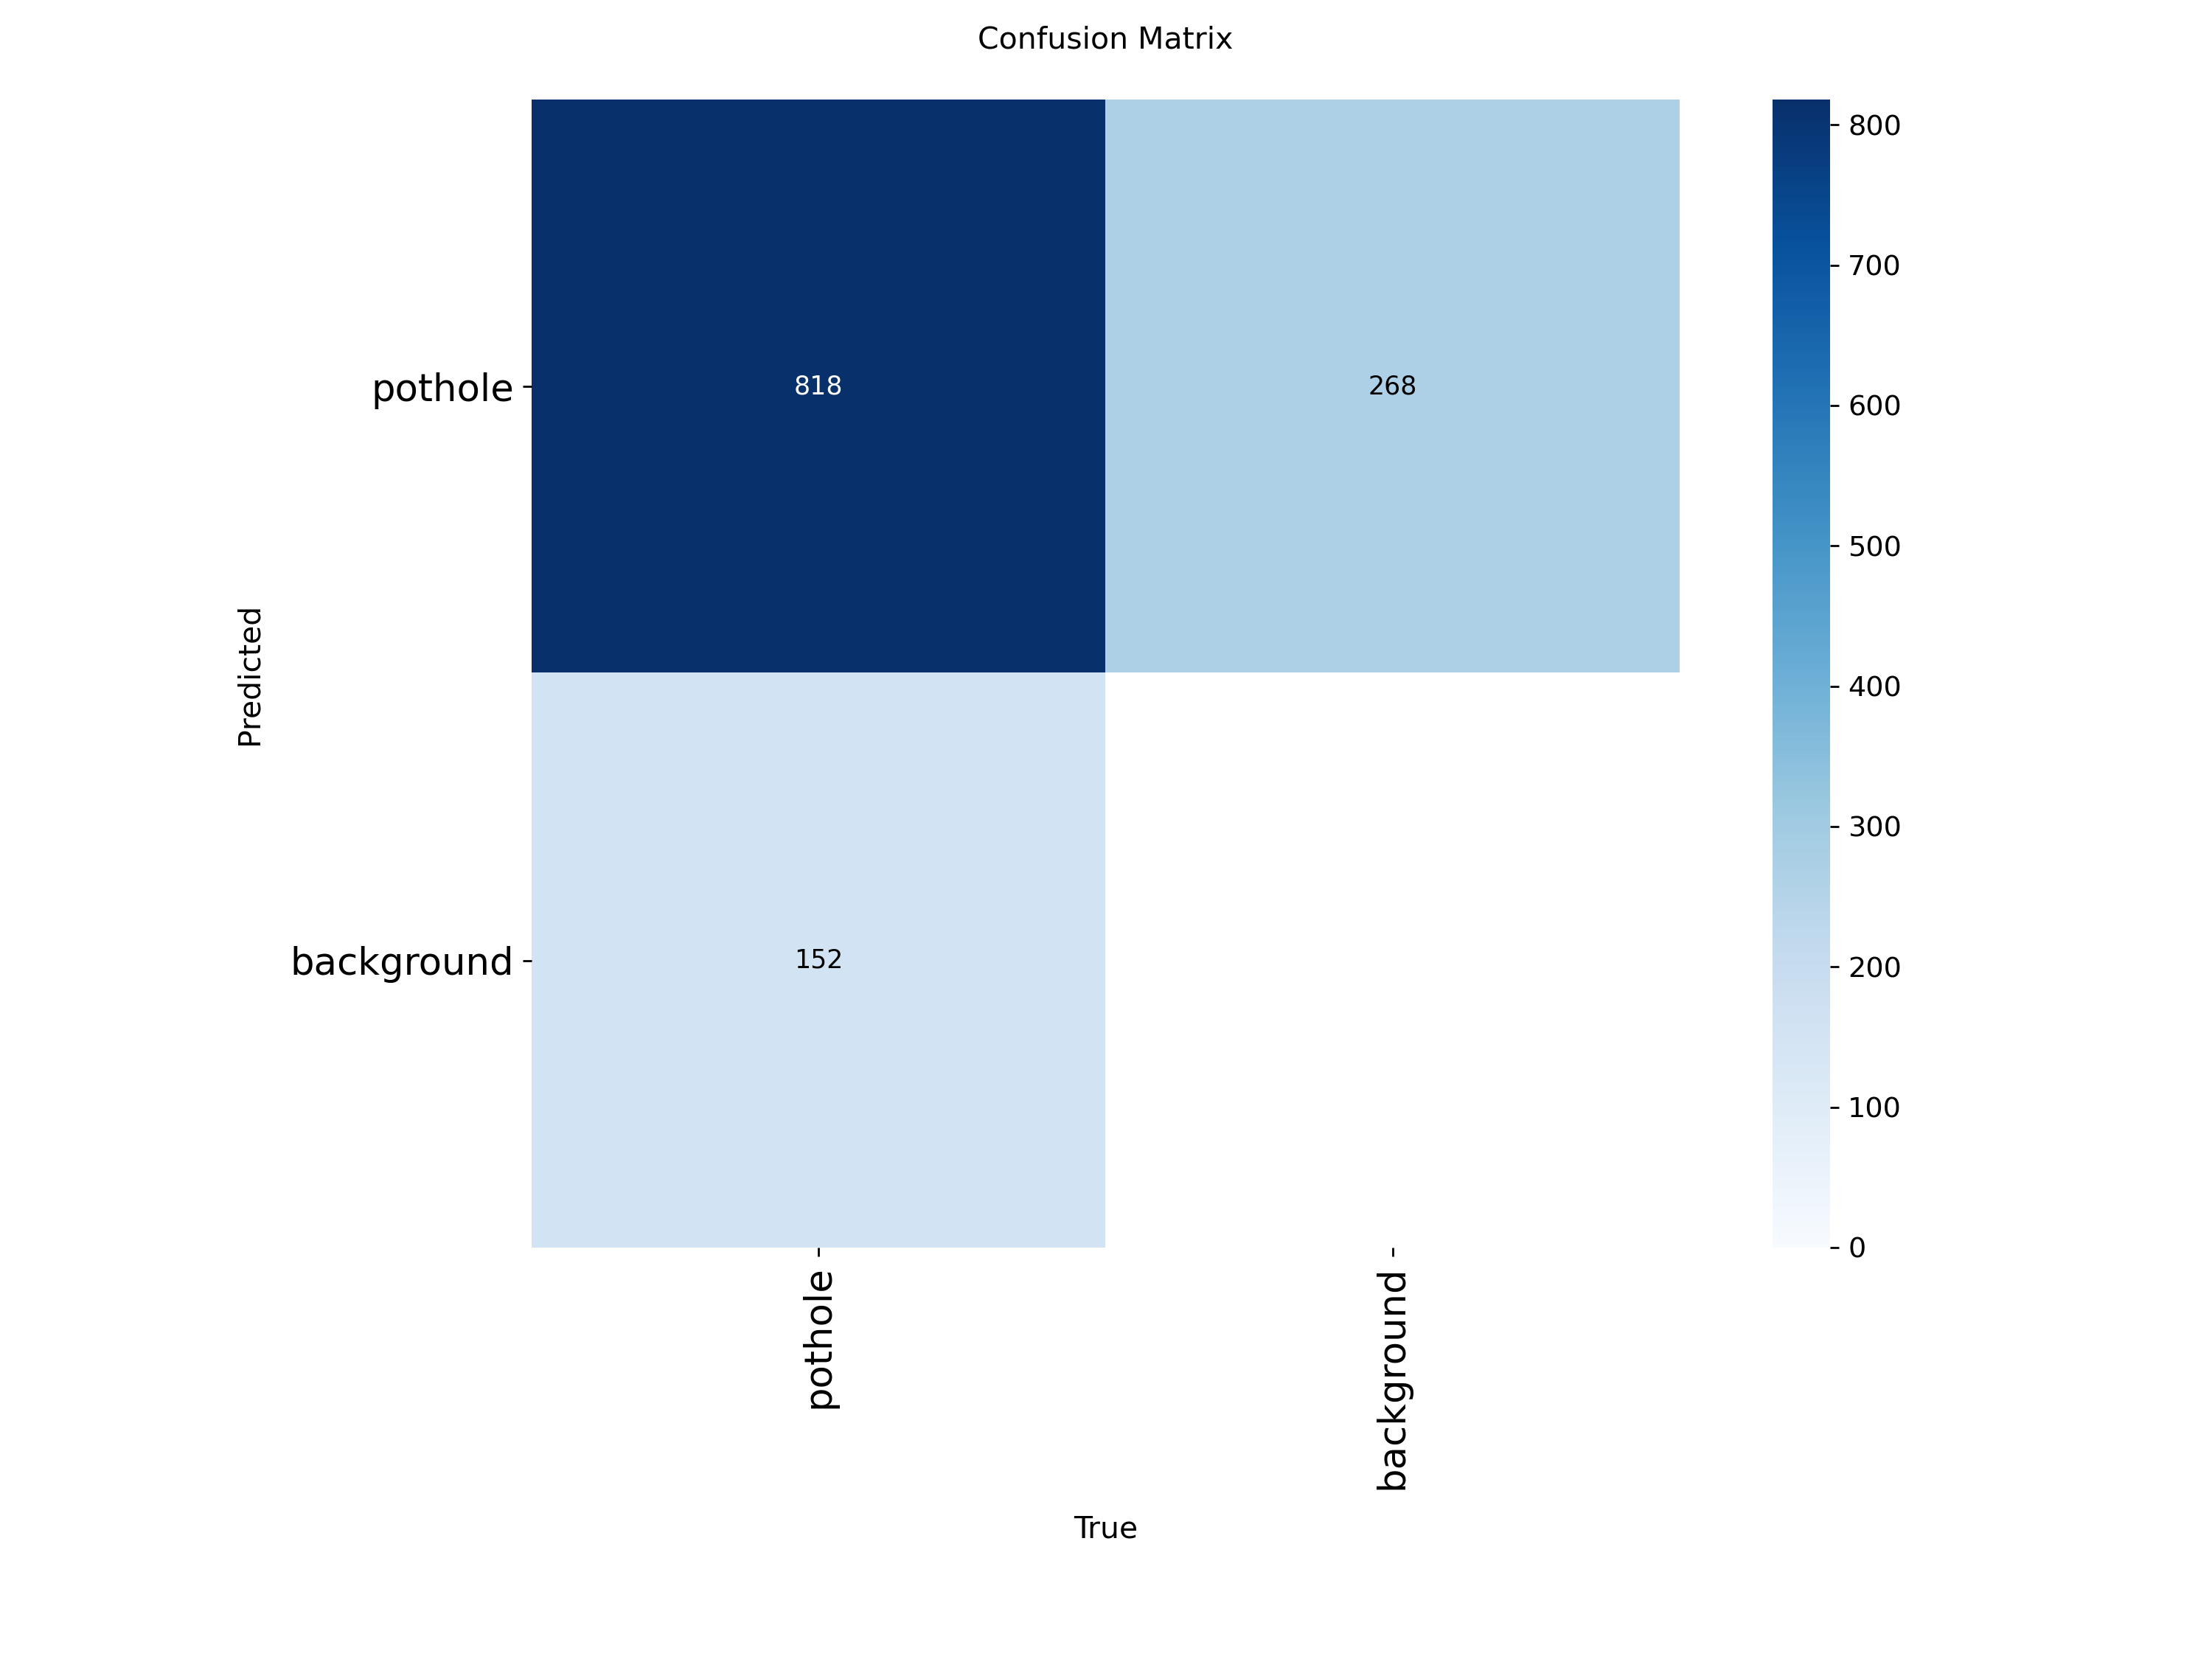

In [14]:
# Display confusion matrix if available
cm_path = f'{PROJECT_DIR}/{RUN_NAME}/confusion_matrix.png'
if os.path.exists(cm_path):
    display(Image(cm_path))
else:
    print("Confusion matrix not found. It's generated during validation.")

## Step 5: Run Inference


image 1/1 /content/Pothole-Detection--10/test/images/135_png.rf.c52a3b983795ee02da5ca67c98817b83.jpg: 352x640 11 potholes, 56.7ms
Speed: 1.7ms preprocess, 56.7ms inference, 1.7ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 /content/Pothole-Detection--10/test/images/img-158_jpg.rf.d93c22ec43d372581676f7b10dd9a292.jpg: 640x640 2 potholes, 18.6ms
Speed: 6.1ms preprocess, 18.6ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Pothole-Detection--10/test/images/img-658_jpg.rf.689201bc7eb23a4a27f326a9608fdfa3.jpg: 640x640 3 potholes, 16.2ms
Speed: 4.7ms preprocess, 16.2ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Pothole-Detection--10/test/images/img-109_jpg.rf.7871236ffa12582ae0a0246b4bb207ab.jpg: 640x640 2 potholes, 16.2ms
Speed: 5.4ms preprocess, 16.2ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


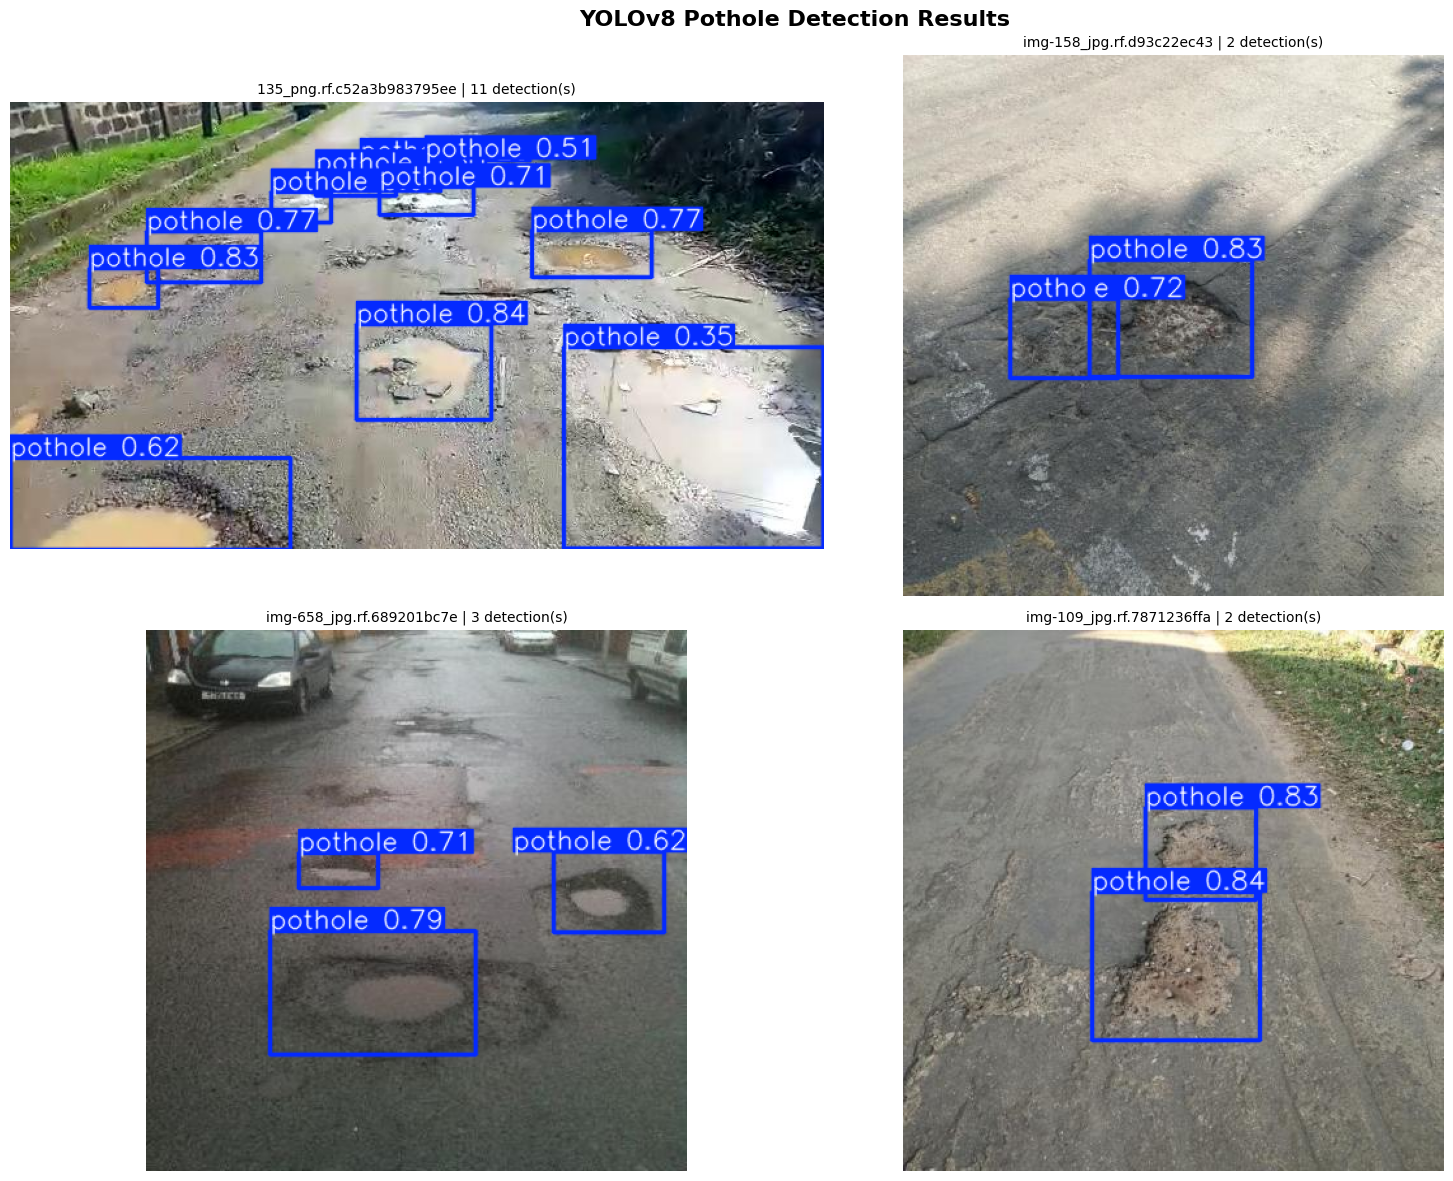


📊 Detection Summary across 4 images:
  class  confidence                 bbox  area_px  area_pct severity
pothole       0.845 [273, 176, 379, 251]     7944      3.53   Medium
pothole       0.826  [62, 132, 117, 163]     1699      0.75      Low
pothole       0.769 [107, 103, 198, 142]     3618      1.61      Low
pothole       0.766 [410, 102, 505, 138]     3497      1.55      Low
pothole       0.709   [291, 67, 364, 89]     1632      0.72      Low
pothole       0.666   [205, 72, 253, 95]     1102      0.49      Low
pothole       0.617   [0, 280, 221, 352]    15791      7.01     High
pothole       0.511   [326, 45, 354, 61]      436      0.19      Low
pothole       0.504   [240, 57, 304, 74]     1107      0.49      Low
pothole       0.352 [435, 194, 640, 352]    32305     14.34     High
pothole       0.283   [276, 47, 306, 57]      313      0.14      Low
pothole       0.832 [144, 158, 268, 247]    11183      6.46     High
pothole       0.720  [83, 187, 165, 249]     5086      2.94   Med

In [15]:
# Inference on test images with detailed analysis
def run_inference_and_analyze(model, image_path, conf_threshold=0.25):
    """Run inference and return detailed analysis."""
    results = model.predict(
        source=image_path,
        conf=conf_threshold,
        iou=0.45,
        save=False
    )[0]

    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    detections = []
    for box in results.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf = float(box.conf[0])
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]
        bbox_area = (x2 - x1) * (y2 - y1)
        img_area = w * h
        severity = 'High' if bbox_area/img_area > 0.05 else ('Medium' if bbox_area/img_area > 0.02 else 'Low')

        detections.append({
            'class': cls_name,
            'confidence': round(conf, 3),
            'bbox': [round(x1), round(y1), round(x2), round(y2)],
            'area_px': round(bbox_area),
            'area_pct': round(bbox_area/img_area*100, 2),
            'severity': severity
        })

    # Annotate image
    annotated = results.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    return annotated_rgb, detections


# Test on validation images
test_img_dir = os.path.join(DATASET_PATH, 'test', 'images')
test_images = [f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('YOLOv8 Pothole Detection Results', fontsize=16, fontweight='bold')

all_detections = []
for ax, img_file in zip(axes.flat, test_images):
    img_path = os.path.join(test_img_dir, img_file)
    annotated, detections = run_inference_and_analyze(best_model, img_path)
    all_detections.extend(detections)

    ax.imshow(annotated)
    ax.set_title(f"{img_file[:25]} | {len(detections)} detection(s)", fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/inference_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Detection Summary across {len(test_images)} images:")
if all_detections:
    df_det = pd.DataFrame(all_detections)
    print(df_det.to_string(index=False))
    print(f"\nAverage confidence: {df_det['confidence'].mean():.3f}")
    print(f"Severity breakdown:\n{df_det['severity'].value_counts().to_string()}")

In [18]:
# ============================================================
# Video Inference (optional — upload a road video)
# ============================================================
from google.colab import files

print("Upload a road video file (.mp4, .avi, .mov):")
uploaded = files.upload()

if uploaded:
    video_path = list(uploaded.keys())[0]
    output_video = f'/content/pothole_detected_{video_path}'

    video_results = best_model.predict(
        source=video_path,
        conf=0.25,
        save=True,
        project='/content',
        name='video_output',
        stream=True
    )

    frame_count = 0
    total_detections = 0
    for r in video_results:
        frame_count += 1
        total_detections += len(r.boxes)

    print(f"\n✅ Video processed!")
    print(f"   Frames processed  : {frame_count}")
    print(f"   Total detections  : {total_detections}")
    print(f"   Avg per frame     : {total_detections/max(frame_count,1):.2f}")
else:
    print("No video uploaded. Skipping video inference.")

## Step 6: Export Model for Flask Deployment

In [17]:
import shutil
from google.colab import files

# Copy best model to /content for easy access
export_path = '/content/pothole_best.pt'
shutil.copy2(BEST_MODEL_PATH, export_path)

print(f"✅ Model exported to: {export_path}")
print(f"   File size: {os.path.getsize(export_path)/1e6:.1f} MB")

# Download the model
print("\n⬇️  Downloading model...")
files.download(export_path)
print("✅ Model downloaded! Place it in your Flask app folder as 'pothole_best.pt'")

✅ Model exported to: /content/pothole_best.pt
   File size: 22.5 MB

⬇️  Downloading model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded! Place it in your Flask app folder as 'pothole_best.pt'


In [ ]:
# Optional: Export to ONNX for cross-platform deployment
best_model.export(format='onnx', imgsz=IMG_SIZE)
onnx_path = BEST_MODEL_PATH.replace('.pt', '.onnx')
shutil.copy2(onnx_path, '/content/pothole_best.onnx')

print("✅ ONNX model exported (optional, for non-PyTorch deployment)")

## Step 7: Road Damage Analytics Dashboard

In [ ]:
# Run batch analysis on the entire test set
def analyze_road_conditions(model, img_dir, conf=0.25, max_images=50):
    """Analyze road conditions across multiple images."""
    images = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))][:max_images]

    stats = {
        'total_images': 0, 'images_with_damage': 0,
        'total_potholes': 0, 'confidences': [],
        'severities': [], 'areas': []
    }

    for img_file in images:
        img_path = os.path.join(img_dir, img_file)
        results = model.predict(source=img_path, conf=conf, verbose=False)[0]

        stats['total_images'] += 1
        n_det = len(results.boxes)

        if n_det > 0:
            stats['images_with_damage'] += 1
            stats['total_potholes'] += n_det
            h, w = results.orig_shape

            for box in results.boxes:
                conf_val = float(box.conf[0])
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                area_pct = (x2-x1)*(y2-y1) / (w*h) * 100
                severity = 'High' if area_pct > 5 else ('Medium' if area_pct > 2 else 'Low')

                stats['confidences'].append(conf_val)
                stats['areas'].append(area_pct)
                stats['severities'].append(severity)

    return stats


print("🔍 Running batch analysis on test set...")
test_stats = analyze_road_conditions(best_model, test_img_dir)

# Dashboard visualization
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Road Damage Analysis Dashboard', fontsize=18, fontweight='bold', y=1.02)

# 1. Summary KPI cards
ax_kpi = fig.add_subplot(3, 3, 1)
kpi_text = (
    f"Total Images:     {test_stats['total_images']}\n"
    f"Damaged Roads:    {test_stats['images_with_damage']}\n"
    f"Damage Rate:      {test_stats['images_with_damage']/max(test_stats['total_images'],1)*100:.1f}%\n"
    f"Total Detections: {test_stats['total_potholes']}\n"
    f"Avg per Image:    {test_stats['total_potholes']/max(test_stats['images_with_damage'],1):.2f}"
)
ax_kpi.text(0.1, 0.5, kpi_text, transform=ax_kpi.transAxes, fontsize=12,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#e8f4fd', alpha=0.8))
ax_kpi.set_title('Summary Statistics', fontweight='bold')
ax_kpi.axis('off')

# 2. Severity distribution
ax2 = fig.add_subplot(3, 3, 2)
if test_stats['severities']:
    from collections import Counter
    sev_counts = Counter(test_stats['severities'])
    colors = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#27ae60'}
    bars = ax2.bar(sev_counts.keys(), sev_counts.values(),
                   color=[colors.get(k, 'gray') for k in sev_counts.keys()], edgecolor='white', linewidth=2)
    ax2.set_title('Damage Severity Distribution', fontweight='bold')
    ax2.set_ylabel('Count')
    for bar, val in zip(bars, sev_counts.values()):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val),
                 ha='center', fontweight='bold')

# 3. Confidence distribution
ax3 = fig.add_subplot(3, 3, 3)
if test_stats['confidences']:
    ax3.hist(test_stats['confidences'], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
    ax3.axvline(np.mean(test_stats['confidences']), color='red', linestyle='--',
                label=f"Mean: {np.mean(test_stats['confidences']):.3f}")
    ax3.set_title('Detection Confidence Distribution', fontweight='bold')
    ax3.set_xlabel('Confidence Score')
    ax3.set_ylabel('Frequency')
    ax3.legend()

# 4. Area distribution
ax4 = fig.add_subplot(3, 3, 4)
if test_stats['areas']:
    ax4.hist(test_stats['areas'], bins=20, color='#e67e22', edgecolor='white', alpha=0.8)
    ax4.set_title('Pothole Area Distribution (% of image)', fontweight='bold')
    ax4.set_xlabel('Area (%)')
    ax4.set_ylabel('Frequency')

# 5. Pie chart - road condition
ax5 = fig.add_subplot(3, 3, 5)
damaged = test_stats['images_with_damage']
undamaged = test_stats['total_images'] - damaged
ax5.pie([damaged, undamaged], labels=['Damaged', 'Good Condition'],
        colors=['#e74c3c', '#27ae60'], autopct='%1.1f%%', startangle=90)
ax5.set_title('Road Condition Overview', fontweight='bold')

# 6. Severity pie
ax6 = fig.add_subplot(3, 3, 6)
if test_stats['severities']:
    sev_counts = Counter(test_stats['severities'])
    colors_list = [colors.get(k, 'gray') for k in sev_counts.keys()]
    ax6.pie(sev_counts.values(), labels=sev_counts.keys(), colors=colors_list,
            autopct='%1.1f%%', startangle=90)
    ax6.set_title('Severity Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/road_damage_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Dashboard saved to /content/road_damage_dashboard.png")

In [ ]:
# Save analytics report as CSV
if test_stats['confidences']:
    report_df = pd.DataFrame({
        'confidence': test_stats['confidences'],
        'area_pct': test_stats['areas'],
        'severity': test_stats['severities']
    })
    report_df.to_csv('/content/pothole_analysis_report.csv', index=False)
    print("✅ Analysis report saved to /content/pothole_analysis_report.csv")
    files.download('/content/pothole_analysis_report.csv')

print("\n🎉 Notebook complete! Next steps:")
print("  1. Download pothole_best.pt")
print("  2. Place it in your Flask app directory")
print("  3. Run: python app.py")
print("  4. Open http://localhost:5000")